In [31]:
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt


In [50]:
exps = [
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x1",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x2",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x3",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x4",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps_x5",
    # "scream_dpxx_DYCOMSrf01_a1_1_0ps_x6",
]

In [51]:
data = {}
for exp in exps:
    larger_path = f"/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/another_larger_domains/{exp}/run/{exp}.scream.h.INSTANT.nmins_x5.1999-*.nc"
    this_name = exp.split("0ps_")[-1]
    print(f"Loading {this_name} from {larger_path}")
    data[this_name] = xr.open_mfdataset(larger_path)

Loading x1 from /pscratch/sd/m/mahf708/dp_screamxx_aero_pert/another_larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x1/run/scream_dpxx_DYCOMSrf01_a1_1_0ps_x1.scream.h.INSTANT.nmins_x5.1999-*.nc
Loading x2 from /pscratch/sd/m/mahf708/dp_screamxx_aero_pert/another_larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x2/run/scream_dpxx_DYCOMSrf01_a1_1_0ps_x2.scream.h.INSTANT.nmins_x5.1999-*.nc
Loading x3 from /pscratch/sd/m/mahf708/dp_screamxx_aero_pert/another_larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x3/run/scream_dpxx_DYCOMSrf01_a1_1_0ps_x3.scream.h.INSTANT.nmins_x5.1999-*.nc
Loading x4 from /pscratch/sd/m/mahf708/dp_screamxx_aero_pert/another_larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x4/run/scream_dpxx_DYCOMSrf01_a1_1_0ps_x4.scream.h.INSTANT.nmins_x5.1999-*.nc
Loading x5 from /pscratch/sd/m/mahf708/dp_screamxx_aero_pert/another_larger_domains/scream_dpxx_DYCOMSrf01_a1_1_0ps_x5/run/scream_dpxx_DYCOMSrf01_a1_1_0ps_x5.scream.h.INSTANT.nmins_x5.1999-*.nc


In [52]:
data.keys()

dict_keys(['x1', 'x2', 'x3', 'x4', 'x5'])

In [53]:
dfs = {}
for exp in data.keys():
    print(exp)
    dfs[exp] = data[exp][["cdnc_at_cldtop", "LiqWaterPath"]].unify_chunks().to_dataframe()

x1
x2
x3
x4
x5


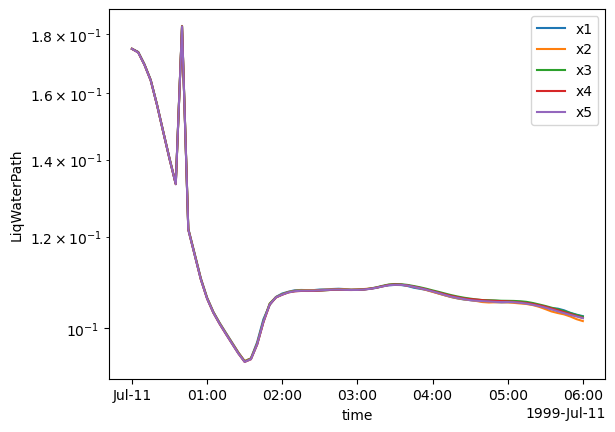

In [54]:
for exp in data.keys():
    data[exp]["LiqWaterPath"].weighted(data[exp].area).mean("ncol").plot(label=exp)
plt.yscale("log")
plt.legend()
plt.savefig("domains_lwp.png", dpi=300)

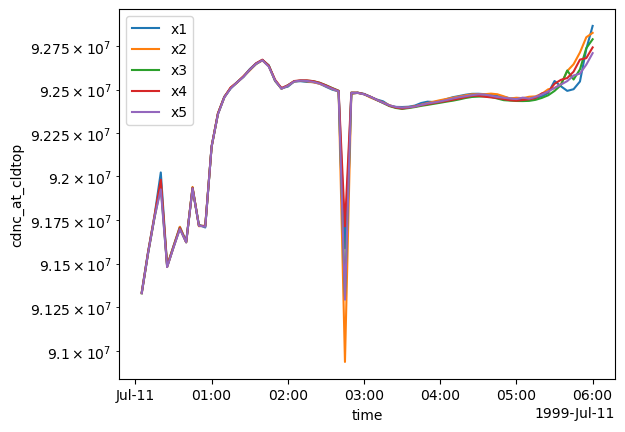

In [55]:
for exp in data.keys():
    data[exp]["cdnc_at_cldtop"].weighted(data[exp].area).mean("ncol").plot(label=exp)
plt.yscale("log")
plt.legend()
plt.savefig("domains_cdnc.png", dpi=300)

In [56]:
# combine the dataframe above and ensure the labels are correct and then the index is reset
big_df = pd.concat(list(dfs.values()), keys=dfs.keys(), axis=0)
big_df["dom"] = [exp for exp in dfs.keys() for _ in range(len(dfs[exp]))]
big_df.reset_index(drop=True, inplace=True)

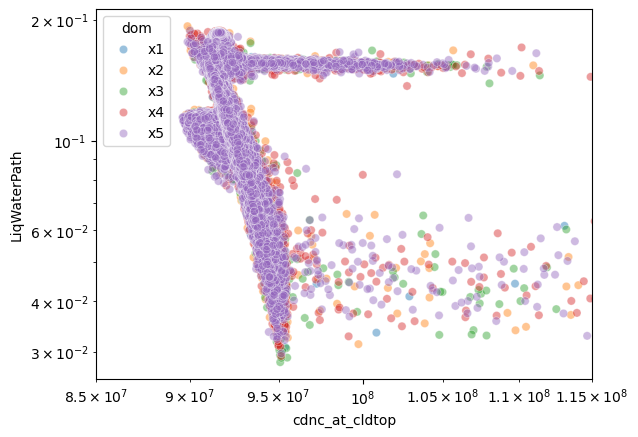

In [57]:
sns.scatterplot(
    data=big_df,
    x="cdnc_at_cldtop",
    y="LiqWaterPath",
    hue="dom",
    alpha=0.45,
)
plt.xscale("log")
plt.yscale("log")
plt.xlim(0.85e8,1.15e8)
plt.savefig("larger_domains_lwp_cdnc.png", dpi=300)

In [27]:
sns.scatterplot(
    data=big_df,
    x="cdnc_at_cldtop_larger",
    y="LiqWaterPath_larger",
    alpha=0.1,
)
plt.xscale("log")
plt.yscale("log")

ValueError: Could not interpret value `cdnc_at_cldtop_larger` for `x`. An entry with this name does not appear in `data`.

In [28]:
import glob
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.pyplot as pyplot
from cartopy import crs as crs
import cartopy.crs as ccrs
import cartopy.feature as cfeature
def fix_lon(x):
    return (x + 180) % 360 - 180

In [29]:
for exp in ["default", "larger"]:

    ds = data[exp]

    for p_var in [
        "cdnc_at_cldtop",
        "LiqWaterPath",
    ]:
        _lon, _lat, p = "lon", "lat", p_var
        vmin, vmax = ds[p].min().values, ds[p].max().values

        for i in range(ds[p].time.size):

            figure, axs = pyplot.subplots(
                1, 1,
                # subplot_kw=dict(projection=ccrs.PlateCarree()),
                figsize=(5, 5)
            )

            ax = axs
            # _ds = ds.isel(time=i).isel(lev=-1)
            # ax.set_extent([-35, -85, -60, -10], crs=ccrs.PlateCarree())


            pl = ax.tripcolor(
                ds[_lon], ds[_lat], ds[p].isel(time=i),
                # transform=crs.PlateCarree(), # cmap="BrBG",
                vmin=vmin, vmax=vmax,
                shading="gouraud"
            )
            # set title with time, convert time to datetime of format yyyy-mm-dd, HH:MM
            ax.set_title(f"DYCOMSII-RF02 {ds.time[i].values.astype('datetime64[m]').astype(str)}", fontsize=8)
            plt.colorbar(pl, ax=ax, fraction=0.046, pad=0.04, label=f"{p} ({ds[p].attrs['units']})", orientation="horizontal")
            # pl.set_norm(LogNorm(vmin=vmin, vmax=vmax))
            figure.tight_layout()
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)

            # save the figure with i integer with 4 zero padding
            plt.savefig(f"gifs/{exp}_{p}_{i:04d}.png", dpi=300, bbox_inches='tight')
            # clear the frame so that we can plot a new one on the same figure next
            pyplot.close()
            print(f"{exp}_{p}_{i:04d}.png saved")
            # plt.close()

/global/u1/m/mahf708/.micromamba/envs/xgns/lib/python3.13/site-packages/xarray/core/common.py:181: RuntimeWarning: invalid value encountered in cast
  return np.array(self.values, dtype=dtype, copy=copy)


default_cdnc_at_cldtop_0000.png saved
default_cdnc_at_cldtop_0001.png saved
default_cdnc_at_cldtop_0002.png saved
default_cdnc_at_cldtop_0003.png saved
default_cdnc_at_cldtop_0004.png saved
default_cdnc_at_cldtop_0005.png saved
default_cdnc_at_cldtop_0006.png saved
default_cdnc_at_cldtop_0007.png saved
default_cdnc_at_cldtop_0008.png saved
default_cdnc_at_cldtop_0009.png saved
default_cdnc_at_cldtop_0010.png saved
default_cdnc_at_cldtop_0011.png saved
default_cdnc_at_cldtop_0012.png saved
default_cdnc_at_cldtop_0013.png saved
default_cdnc_at_cldtop_0014.png saved
default_cdnc_at_cldtop_0015.png saved
default_cdnc_at_cldtop_0016.png saved
default_cdnc_at_cldtop_0017.png saved
default_cdnc_at_cldtop_0018.png saved
default_cdnc_at_cldtop_0019.png saved
default_cdnc_at_cldtop_0020.png saved
default_cdnc_at_cldtop_0021.png saved
default_cdnc_at_cldtop_0022.png saved
default_cdnc_at_cldtop_0023.png saved
default_cdnc_at_cldtop_0024.png saved
default_cdnc_at_cldtop_0025.png saved
default_cdnc

/global/u1/m/mahf708/.micromamba/envs/xgns/lib/python3.13/site-packages/xarray/core/common.py:181: RuntimeWarning: invalid value encountered in cast
  return np.array(self.values, dtype=dtype, copy=copy)


larger_cdnc_at_cldtop_0000.png saved
larger_cdnc_at_cldtop_0001.png saved
larger_cdnc_at_cldtop_0002.png saved
larger_cdnc_at_cldtop_0003.png saved
larger_cdnc_at_cldtop_0004.png saved
larger_cdnc_at_cldtop_0005.png saved
larger_cdnc_at_cldtop_0006.png saved
larger_cdnc_at_cldtop_0007.png saved
larger_cdnc_at_cldtop_0008.png saved
larger_cdnc_at_cldtop_0009.png saved
larger_cdnc_at_cldtop_0010.png saved
larger_cdnc_at_cldtop_0011.png saved
larger_cdnc_at_cldtop_0012.png saved
larger_cdnc_at_cldtop_0013.png saved
larger_cdnc_at_cldtop_0014.png saved
larger_cdnc_at_cldtop_0015.png saved
larger_cdnc_at_cldtop_0016.png saved
larger_cdnc_at_cldtop_0017.png saved
larger_cdnc_at_cldtop_0018.png saved
larger_cdnc_at_cldtop_0019.png saved
larger_cdnc_at_cldtop_0020.png saved
larger_cdnc_at_cldtop_0021.png saved
larger_cdnc_at_cldtop_0022.png saved
larger_cdnc_at_cldtop_0023.png saved
larger_cdnc_at_cldtop_0024.png saved
larger_cdnc_at_cldtop_0025.png saved
larger_cdnc_at_cldtop_0026.png saved
l

In [30]:
import imageio

for exp in ["default", "larger"]:

    for p_var in [
        "cdnc_at_cldtop",
        "LiqWaterPath",
    ]:
        images = []
        filenames = glob.glob(f'gifs/{exp}_{p_var}_????.png')
        filenames.sort()
        for filename in filenames:
            images.append(imageio.imread(filename))
        imageio.mimsave(f'{exp}_{p_var}.gif', images, loop=0)

/tmp/ipykernel_711695/93929509.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))
